In [ ]:
# !pip install moomoo-api
# !pip install matplotlib inline
# !pip install finnhub-python
# !pip install python-dotenv
# !pip install seaborn
# !pip install playwright
# !playwright install chromium

# 牛来

In [1]:
from moomoo import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures
import urllib.request

# quote_ctx gets the market data from moomoo server, and trade_ctx gets the trading data from moomoo server.
quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)  # Create quote object
print(quote_ctx.get_market_snapshot('HK.00700'))  # Get market snapshot for HK.00700
quote_ctx.close() # Close object to prevent the number of connextions from running out
print("----------------------------------------------")
trd_ctx = OpenSecTradeContext(host='127.0.0.1', port=11111)  # Create trade object
print(trd_ctx.place_order(price=500.0, qty=100, code="HK.00700", trd_side=TrdSide.BUY, trd_env=TrdEnv.SIMULATE))  # Placing an order through paper trading account (Live trading requires unlocking first; if using the GUI version of OpenD, skip this step and unlock manually by clicking the Unlock button on the UI)

trd_ctx.close()  # Close object to prevent the number of connextions from running out

2026-09-20 15:14:47,658 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507336443288350599(1) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x000002055EE49850>
(0,        code     name          update_time  last_price  open_price  high_price  \
0  HK.00700  TENCENT  2026-09-18 16:07:30       419.0       428.0       430.4   

   low_price  prev_close_price      volume      turnover  ...  \
0      419.0             426.0  28796138.0  1.218079e+10  ...   

   after_change_rate  after_amplitude overnight_price  overnight_high_price  \
0                N/A              N/A             N/A                   N/A   

   overnight_low_price  overnight_volume  overnight_turnover  \
0                  N/A               N/A                 N/A   

   overnight_change_val  overnight_change_rate  overnight_amplitude  
0                   N/A                    N/A                  N/A  

[1 rows x 142 columns])
--------------------------

## Sentiment correlation in financial news networks and associated market movements pipeline

In [2]:
# load finnhub news
import os
from dotenv import load_dotenv
import finnhub
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import json
from playwright.async_api import async_playwright
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

load_dotenv(dotenv_path = '../main/.env')  
FINNHUB_API_KEY = os.getenv('FINNHUB_API_KEY')
# today_date = datetime.datetime.now().strftime("%Y-%m-%d")

finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

def date_days_ago(days, curr_date):
    return (curr_date - timedelta(days=days)).strftime("%Y-%m-%d")

def get_sixtyd_rolling_window(company_code):
    # uese us market open date to avoid lookahead bias
    us_market_time_open = datetime.now(ZoneInfo("America/New_York")).replace(hour=9, minute=30, second=0, microsecond=0)
    us_market_time_open_date = us_market_time_open.strftime("%Y-%m-%d")
    sixtyd_ago_date = date_days_ago(60, us_market_time_open)
    us_market_time_open_ts = int(us_market_time_open.timestamp())
    sixtyd_window_news = finnhub_client.company_news(company_code, _from=sixtyd_ago_date, to=us_market_time_open_date)
    # filter
    filtered_sixtyd_window_news = [article for article in sixtyd_window_news if article['datetime'] < us_market_time_open_ts]
    return filtered_sixtyd_window_news


sixtyd_window_news_amzn = get_sixtyd_rolling_window('AMZN')

print(len(sixtyd_window_news_amzn))

sixtyd_window_news_amzn[0:5]

248


[{'category': 'company',
  'datetime': 1789688467,
  'headline': 'Why Generac Stock Soared Today',
  'id': 142231740,
  'image': 'https://s.yimg.com/rz/stage/p/yahoo_finance_en-US_h_p_finance_2.png',
  'related': 'AMZN',
  'source': 'Yahoo',
  'summary': 'A long-term supply deal with an AI juggernaut has investors excited.',
  'url': 'https://finnhub.io/api/news?id=03375cdefa167d9101123c7ca918e689e9c867849f4cc31ac78c3fd2f5b82690'},
 {'category': 'company',
  'datetime': 1789688435,
  'headline': "AI Security Debate — Amazon Says AI Models To Be Released Only When 'Ready And Safe'",
  'id': 142234904,
  'image': 'https://s.yimg.com/rz/stage/p/yahoo_finance_en-US_h_p_finance_2.png',
  'related': 'AMZN',
  'source': 'Yahoo',
  'summary': 'Amazon advocates for thorough testing and public-private oversight over hasty AI deployments.',
  'url': 'https://finnhub.io/api/news?id=1d84384e01b2b8eaadbfd8875d0ee646ec5e32dbce1d8e5689771736e2e192b2'},
 {'category': 'company',
  'datetime': 1789683734

In [114]:
# 
us_company_codes = [
    # cloud
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "CRM", "ORCL",
    # chips
    "NVDA", "AMD", "AVGO", "INTC", "CSCO", "IBM",
    # retail
    "TSLA", "WMT", "TGT", "COST", "MCD", "SBUX", "GM", "HD",
    # banking
    "JPM", "GS", "MS", "BAC", "WFC", "AXP", "V", "MA", "BRK.B",
    # sector anchor
    "PG", "KO", "PEP", "JNJ", "PFE", "LLY", "UNH", "GE", "CAT", "BA", "XOM", "CVX"

]

news_metadata = []


for code in us_company_codes:
    try:
        news = get_sixtyd_rolling_window(code)
        news_metadata  += news
        print(f"company {code} processed! Total of {len(news)} news")
    except Exception as e:
        print('error processing: '+ code + f"\n{e}")

dedup = list({article['id']: article for article in news_metadata}.values())

# write to json
with open('news_metadata.json', 'w') as f:
    json.dump(dedup, f)

len(dedup)

company AAPL processed! Total of 242 news
company MSFT processed! Total of 248 news
company GOOGL processed! Total of 249 news
company AMZN processed! Total of 249 news
company META processed! Total of 244 news
company NFLX processed! Total of 240 news
company CRM processed! Total of 241 news
company ORCL processed! Total of 249 news
company NVDA processed! Total of 239 news
company AMD processed! Total of 246 news
company AVGO processed! Total of 245 news
company INTC processed! Total of 243 news
company CSCO processed! Total of 230 news
company IBM processed! Total of 232 news
company TSLA processed! Total of 237 news
company WMT processed! Total of 246 news
company TGT processed! Total of 246 news
company COST processed! Total of 247 news
company MCD processed! Total of 228 news
company SBUX processed! Total of 246 news
company GM processed! Total of 249 news
company HD processed! Total of 237 news
company JPM processed! Total of 243 news
company GS processed! Total of 232 news
comp

7962

In [4]:
# from datetime import datetime, timedelta
# from zoneinfo import ZoneInfo



# def update_cached_news_metadata(finnhub_client):

#     cached_news_metadata = None
#     with open('news_metadata.json', 'r') as f:
#         cached_news_metadata = json.load(f)

#     all_dates = [article['datetime'] for article in cached_news_metadata]
#     latest_cached_date_ts = max(all_dates)

#     latest_cached_date = datetime.fromtimestamp(latest_cached_date_ts).strftime("%Y-%m-%d")

#     # use the US market time opening time
#     us_market_time_open = datetime.now(ZoneInfo("America/New_York")).replace(hour=9, minute=30, second=0, microsecond=0)
#     sixtyd_from_us_date = us_market_time_open- timedelta(60)

#     us_market_time_open_date = us_market_time_open.strftime("%Y-%m-%d")
#     us_market_time_open_ts = int(us_market_time_open.timestamp())
#     sixtyd_from_us_date_ts = int(sixtyd_from_us_date.timestamp())

#     us_company_codes = [
#         # cloud
#         "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NFLX", "CRM", "ORCL",
#         # chips
#         "NVDA", "AMD", "AVGO", "INTC", "CSCO", "IBM",
#         # retail
#         "TSLA", "WMT", "TGT", "COST", "MCD", "SBUX", "GM", "HD",
#         # banking
#         "JPM", "GS", "MS", "BAC", "WFC", "AXP", "V", "MA", "BRK.B",
#         # sector anchor
#         "PG", "KO", "PEP", "JNJ", "PFE", "LLY", "UNH", "GE", "CAT", "BA", "XOM", "CVX"
#         ]

#     # filter away the timestamps that are before this date
#     print("removing articles outside the roling 60 day date window...")
#     filtered_cached_news_metadata = [article for article in cached_news_metadata if article['datetime'] > sixtyd_from_us_date_ts]

#     # populate the filtered list with new news
#     for code in us_company_codes:
#         try:
#             data = finnhub_client.company_news(code, _from=latest_cached_date, to=us_market_time_open_date)
#             filtered_cached_news_metadata += data
#             print(f"company {code} processed! Total of {len(data)} news")
#         except Exception as e:
#              print(e)
             

#     # second filtering to filter away articles after the market open date today
#     filtered_cached_news_metadata = [article for article in filtered_cached_news_metadata if article['datetime'] < us_market_time_open_ts]

#     # remove dups
#     dedup_filtered_cached_news_metadata = list({article['id']: article for article in filtered_cached_news_metadata}.values())
#     print(f"dups resolved from {len(filtered_cached_news_metadata)} to {len(dedup_filtered_cached_news_metadata)}")

#     # write to json
#     with open('news_metadata.json', 'w') as f:
#         try:
#             json.dump(dedup_filtered_cached_news_metadata, f)
#         except Exception as e:
#                 print('error processing: '+ code + f"\n{e}")

#     print("metadata successfully updated!")


# update_cached_news_metadata(finnhub_client)

In [16]:
# load news from cache
cached_news_metadata = None
with open('../cache/news_metadata.json', 'r') as f:
    cached_news_metadata = json.load(f)

cached_news_articles = None
with open('../cache/news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)

def load_url(url, timeout):
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
    }

    response = requests.get(url, headers=headers, timeout=timeout)
    response.raise_for_status()

    return response.content

def get_text_from_html(data):
    soup = BeautifulSoup(data, 'html.parser')
    paragraphs = soup.find_all("p")
    article_text = "\n".join(p.get_text(" ", strip=True).lower() for p in paragraphs)
    return article_text

# articles that have not been processed and insdie the metadata
# urls = list(set([news['url'] for news in cached_news_metadata if news['url'] not in cached_news_articles]))


# print(f"processing {len(urls)} urls")
# completed = 0
# with concurrent.futures.ThreadPoolExecutor(max_workers=7) as executor:
#     # Start the load operations and mark each future with its URL
#     future_to_url = {executor.submit(load_url, url, 30): url for url in urls}
#     for future in concurrent.futures.as_completed(future_to_url):
#         url = future_to_url[future]
#         try:
#             data = future.result()

#             # convert to text
#             article_text = get_text_from_html(data)

#             # append to list
#             if article_text:
#                 cached_news_articles[url] = article_text
#                 print(f"{url} successfully processed!")

#         except Exception as exc:
#             print('%r generated an exception: %s' % (url, exc))

#         completed += 1
#         if completed % 25 == 0:
#             print(f"{completed}/{len(urls)} completed")

# # remove articles not present in the metadata
# metadata_urls = [news['url'] for news in cached_news_metadata]
# filtered_cached_news_articles = {url: text for url, text in cached_news_articles.items() if url in metadata_urls}

# with open('news_articles.json', 'w') as f:
#     json.dump(filtered_cached_news_articles , f)

# len(cached_news_articles),"to", len(filtered_cached_news_articles)

In [6]:
cached_news_articles = None
with open('../cache/news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)

cached_news_articles['https://finnhub.io/api/news?id=09613e0f024d6e9a93a4fae59e397966020f784dac0f8568f0939d08ead595db']

"oops, something went wrong\nmagnolia oil & gas (mgy) said monday that it has signed a definitive agreement to acquire wildfire energy for about $4.06 billion, including debt and subject to customary purchase price adjustments. under the terms of the deal, wildfire shareholders will receive 32.2 million magnolia shares, and magnolia will also assume wildfire's $600 million of outstanding notes due 2029, according to a statement. magnolia said it intends to fund the remaining amount through existing cash, debt, and new equity. the company said it has also secured committed financing from jpmorgan chase (jpm), citigroup (c) global markets, and wells fargo (wfc). the company added that it has amended its secured credit facility to a $2 billion borrowing base, with elected commitments of $1.75 billion subject to the transaction's completion. magnolia said it expects the acquisition to be immediately and highly accretive to its cash flow and earnings per share, and to generate over $100 mil

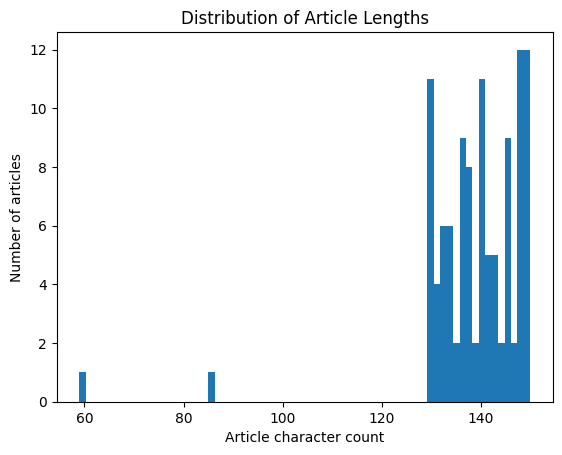

In [10]:
import matplotlib.pyplot as plt

lengths = [len(text) for text in cached_news_articles.values() if len(text) <= 150 and 'oops, something went wrong' in text]

plt.hist(lengths, bins=70)
plt.xlabel("Article character count")
plt.ylabel("Number of articles")
plt.title("Distribution of Article Lengths")
plt.show()

print()

In [11]:
ct = 0
for url, text in cached_news_articles.items():
    if len(text) <= 140 and 'oops, something went wrong' in text:
        print("=" * 100)
        print("Length:", len(text))
        print("URL:", url)
        print("TEXT:", repr(text))
        ct += 1
ct

Length: 134
URL: https://finnhub.io/api/news?id=b81902b3dc8ae5b14b3f489d0534f7927faa6711556d540d4b956e4260400c84
TEXT: 'oops, something went wrong\nmorgan stanley analyst kristine liwag on wednesday upgraded shares of honeywell aerospace to buy from hold.'
Length: 130
URL: https://finnhub.io/api/news?id=0656ce3215d6ecb2f9ae9fd570c43ba90a45a74cc55f8b3d38e402f014c90681
TEXT: 'oops, something went wrong\ncapital one results beat wall street’s expectations. the bank noted signs of improving consumer credit.'
Length: 136
URL: https://finnhub.io/api/news?id=571938922c53a24695a79bd4b7bcf6cadc277e382964d905e6dd29c162da8113
TEXT: 'oops, something went wrong\nsummit says its ivonescimab is keeping lung-cancer patients alive longer than keytruda does. the stock is up.'
Length: 136
URL: https://finnhub.io/api/news?id=ac9df71a84fd316ae7d0c75d50900947c03bcd0fe4f2caa6500a2267257a7326
TEXT: 'oops, something went wrong\ndell reported better-than-expected second-quarter financial results after the stock

61

In [18]:
data = load_url("https://finnhub.io/api/news?id=25aeb44b56fdd20c2fbb9f307c3b06084c52f1427f4e9e95d1593db372bd106b", 20)
# get_text_from_html(data)
soup = BeautifulSoup(data, 'html.parser')
paragraphs = soup.find_all("p")
article_text = "\n".join(p.get_text(" ", strip=True) for p in paragraphs)
print(article_text)
print(len(article_text))

Oops, something went wrong
Healthcare stocks were higher late Wednesday afternoon, with the NYSE Healthcare Index and the State
127


In [19]:
from playwright.async_api import async_playwright

p = await async_playwright().start()
browser = await p.chromium.launch(headless=True)

page = await browser.new_page()
url = "https://finnhub.io/api/news?id=571938922c53a24695a79bd4b7bcf6cadc277e382964d905e6dd29c162da8113"
response = await page.goto(url, wait_until="domcontentloaded")

html = await page.content()

soup = BeautifulSoup(html, 'html.parser')
paragraphs = soup.find_all("p")
article_text = "\n".join(p.get_text(" ", strip=True) for p in paragraphs)
article_text.split("\n")

['Oops, something went wrong',
 'Tip: Try a valid symbol or a specific company name for relevant results',
 'Summit says its ivonescimab is keeping lung-cancer patients alive longer than Keytruda does. The stock is up.',
 'Tip: Try a valid symbol or a specific company name for relevant results',
 'Sign in to access your portfolio']

Playwright solves the partial-text issue by running the webpage’s JavaScript and waiting for dynamically loaded content to populate the DOM before scraping it, whereas requests only retrieves the initial HTML response without executing that JavaScript.

In [ ]:
# run a playwright script to repla ce all the partial text present in the cached dict (resolve partial article texts)

from playwright.async_api import async_playwright

p = await async_playwright().start()
browser = await p.chromium.launch(headless=True)
page = await browser.new_page()


# load
cached_news_articles = None
with open('news_articles.json', 'r') as f:
    cached_news_articles = json.load(f)


for url, text in cached_news_articles.items():
    if len(text) <= 128 and 'oops, something went wrong' in text:
        try:

            response = await page.goto(url, wait_until="domcontentloaded")
            data = await page.content()
            article_text = get_text_from_html(data)
            
            # append to list
            if article_text:
                cached_news_articles[url] = article_text
                print(f"{url} successfully processed!")
        except Exception as e:
            print(f"{url} still failed with exception: {e}")

await page.close()
await browser.close()
await p.stop()

# overwrite
with open('news_articles.json', 'w') as f:
    json.dump(cached_news_articles , f)

https://finnhub.io/api/news?id=f82b5af8e393a17885549231c43f3cc1a7d77ea538f549e55695793b8f81b696 successfully processed!
https://finnhub.io/api/news?id=19a181ba26768450407baf30a75c6e78bb4bad8e0b2b60956b38bd5267bc4049 successfully processed!
https://finnhub.io/api/news?id=41395eb04231ea23c262e52408bb6641457a13852b199aa26806a20a6c85740d successfully processed!
https://finnhub.io/api/news?id=f170b3df6972343cca61f3e354f0bf4891679a5ca3be81367d1bd7db48eb7ac7 successfully processed!
https://finnhub.io/api/news?id=a0f13dd5872071e48126d8f286cf349883f0aa21324db1d5f38cc039ab90448d successfully processed!
https://finnhub.io/api/news?id=9cf3fd61c9110cd03771e019f5f2252003b6aa7e5fe64b52287d4d498c391779 successfully processed!
https://finnhub.io/api/news?id=2e39a85bb0942e0dd51845bcf506f75c18d50df5ddf7c0f1353c03e9b801f473 successfully processed!
https://finnhub.io/api/news?id=96a1130f5ec9246e04e0c26ae0cee2a2eccdb48b04e182750c3225900cbd0efd successfully processed!
https://finnhub.io/api/news?id=dd2236e5d

# More of moomoo

In [2]:
from moomoo import *
import time

quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
simple_filter = SimpleFilter()
simple_filter.filter_min = 2
simple_filter.filter_max = 1000
simple_filter.stock_field = StockField.CUR_PRICE
simple_filter.is_no_filter = False
# simple_filter.sort = SortDir.ASCEND

financial_filter = FinancialFilter()
financial_filter.filter_min = 0.5
financial_filter.filter_max = 50
financial_filter.stock_field = StockField.CURRENT_RATIO
financial_filter.is_no_filter = False
financial_filter.sort = SortDir.ASCEND
financial_filter.quarter = FinancialQuarter.ANNUAL

custom_filter = CustomIndicatorFilter()
custom_filter.ktype = KLType.K_DAY
custom_filter.stock_field1 = StockField.KDJ_K
custom_filter.stock_field1_para = [10,4,4]
custom_filter.stock_field2 = StockField.KDJ_K
custom_filter.stock_field2_para = [9,3,3]
custom_filter.relative_position = RelativePosition.MORE
custom_filter.is_no_filter = False

accumulate_filter = AccumulateFilter()
accumulate_filter.stock_field = StockField.AMPLITUDE
accumulate_filter.filter_max = 40
accumulate_filter.filter_min = 30
accumulate_filter.sort = SortDir.DESCEND

nBegin = 0
last_page = False
ret_list = list()
while not last_page:
    nBegin += len(ret_list)
    ret, ls = quote_ctx.get_stock_filter(market=Market.SG, filter_list=[accumulate_filter], begin=nBegin)  # filter with simple, financial and indicator filter for HK market
    if ret == RET_OK:
        last_page, all_count, ret_list = ls
        print('all count = ', all_count)
        for item in ret_list:
            print(item.stock_code)  # Get the stock code
            print(item.stock_name)  # Get the stock name
            #print(item[simple_filter])   # Get the value of the variable corresponding to simple_filter
            #print(item[financial_filter])   # Get the value of the variable corresponding to financial_filter 
            #print(item[custom_filter])  # Get the value of custom_filter
            print(item[accumulate_filter])
    else:
        print('error: ', ls)
        break
    time.sleep(3)  # Sleep for 3 seconds to avoid trigger frequency limitation

quote_ctx.close()  # After using the connection, remember to close it to prevent the number of connections from running out


2026-09-20 15:45:21,365 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507344134459644734(3) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x0000020561631AF0>
all count =  468
SG.YSV
Khen Energy
500.0
SG.579
Oceanus
100.0
SG.532
DISA
100.0
SG.1D5
Capital World
100.0
SG.5FX
New Wave
50.0
SG.1H3
Clearbridge
50.0
SG.V3M
Metech Intl
37.142
SG.AWZ
Multi-Chem
29.032
SG.BTOU
ManulifeReit USD
27.083
SG.584
AJJ Medtech
25.0
SG.BHD
China Mining
21.428
SG.BLU
GRP
19.607
SG.9MT
METAOPTICS LTD
17.808
SG.NHD
Jubilee
17.391
SG.BKK
Luxking
14.285
SG.KIN
KIN
12.994
SG.QZG
Accrelist Ltd
12.903
SG.AVX
HL Global Ent
12.857
SG.OXMU
Prime US ReitUSD
12.781
SG.D03
Del Monte Pac
12.698
SG.D5IU
Landmark REIT
12.5
SG.5KI
Soup Holdings
12.5
SG.BDU
Federal Int
12.244
SG.T12
Tat Seng Pkg
11.111
SG.R14
Eneco Energy
11.111
SG.S71
Sunright
10.714
SG.Q0F
IHH
10.612
SG.5HH
ProsperaGlobal
10.0
SG.LS9
Leader Env
10.0
SG.40W
ZICO Hldgs
9.433
SG.D01
DFIRG USD


In [8]:
quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
ret, data = quote_ctx.get_plate_list(Market.US, Plate.CONCEPT)
data_plate_list = [code for code in data.code]
quote_ctx.close()
print(data_plate_list[:5])
data

2026-09-20 15:48:04,784 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507344819785981162(7) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x00000205617FF4D0>


['US.LIST20010', 'US.LIST20077', 'US.LIST20745', 'US.LIST20882', 'US.LIST20883']
2026-09-20 15:48:04,810 | 15140 | 11452 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(7) reason=CallClose


,code,plate_name,plate_id
0,US.LIST20010,Crypto,LIST20010
1,US.LIST20077,Semiconductors,LIST20077
2,US.LIST20745,Japanese Companies,LIST20745
3,US.LIST20882,NVIDIA Portfolio,LIST20882
4,US.LIST20883,Nancy Pelosi Portfolio,LIST20883
...,...,...,...
112,US.LIST2655,Blockchain,LIST2655
113,US.LIST2657,Digital Payment,LIST2657
114,US.LIST2997,Cannabis & Hemp,LIST2997
115,US.LIST2998,Singles' Day Sales,LIST2998


In [10]:
quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
ret, data = quote_ctx.get_plate_list(Market.US, Plate.CONCEPT)
ret, data_plate = quote_ctx.get_market_snapshot(data_plate_list)
quote_ctx.close()

data_plate = data_plate.merge(data, on='code')
data_plate.set_index("plate_name", inplace=True)
data_plate['price_change'] = (data_plate['last_price'] / data_plate['prev_close_price'])
data_plate_top20 = data_plate[['code','price_change', 'last_price', 'open_price', 'high_price', 'low_price', 'prev_close_price']].sort_values(by='price_change', ascending=False)[:20]
data_plate_top20

2026-09-20 15:48:27,829 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507344916452056646(9) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x00000205617FF650>


,code,price_change,last_price,open_price,high_price,low_price,prev_close_price
plate_name,,,,,,,
SOL reserve concept,US.LIST23797,1.136189,12.129137,11.079056,12.514784,10.748797,10.675282
Crypto Treasury,US.LIST23920,1.122740,725.829049,666.505777,726.433819,665.505354,646.479916
ETH-Holding Companies,US.LIST23775,1.110310,899.323912,833.265382,905.351828,831.484413,809.975741
Crypto,US.LIST20010,1.092967,934.089344,879.340315,934.407233,875.882130,854.636433
Crypto Mining,US.LIST23921,1.079787,1883.356987,1795.799526,1886.922080,1757.719017,1744.193129
OLED Technology,US.LIST2448,1.063733,2558.156827,2434.575130,2560.224911,2423.480579,2404.886020
Solar Power,US.LIST2450,1.050752,10687.894689,10287.205716,10692.489443,10236.883372,10171.663178
Non-Fungible Tokens,US.LIST2561,1.045234,1091.686264,1066.441461,1094.305911,1065.681269,1044.442424
Data storage stock,US.LIST23925,1.039944,12208.391194,11856.438302,12302.461788,11800.461173,11739.475065


2026-09-20 15:48:27,931 | 15140 | 11452 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(9) reason=CallClose


In [40]:
from datetime import datetime
past_week = (datetime.now()- timedelta(days=5)).strftime("%Y-%m-%d")
now = datetime.now().strftime("%Y-%m-%d")

data_plate_top20_codes = data_plate_top20.code.to_list()

quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
data_plate_top20_kline = []
for code in data_plate_top20_codes:
    ret, history_data, page_req_key= quote_ctx.request_history_kline(code, start=past_week, end=now) # 4 days returned becasue 12 is a sunday
    if ret == RET_OK:
        data_plate_top20_kline.append(history_data)
    else:
        print('error')

quote_ctx.close()
data_plate_top20_kline = ((pd.concat(data_plate_top20_kline, ignore_index=True)).merge(data, on='code', how='left')).set_index(['code', 'plate_name','time_key' ])

cumprod_table = (data_plate_top20_kline.unstack(-1).change_rate /100 + 1).cumprod(axis=1).sort_values(by='2026-09-18 00:00:00', ascending=False)
cumprod_table

2026-09-20 22:33:41,877 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507446897053016022(31) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x0000020561834080>
2026-09-20 22:33:42,263 | 15140 | 11452 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(31) reason=CallClose


,time_key,2026-09-15 00:00:00,2026-09-16 00:00:00,2026-09-17 00:00:00,2026-09-18 00:00:00
code,plate_name,,,,
US.LIST23921,Crypto Mining,0.952551,0.985932,1.021681,1.103198
US.LIST2553,3D Printing,1.001722,1.029934,1.077675,1.091675
US.LIST23925,Data storage stock,0.993956,0.994569,1.042239,1.083870
US.LIST23920,Crypto Treasury,0.928815,0.908145,0.952541,1.069456
US.LIST2521,Data Center,1.007233,1.018727,1.053129,1.067309
US.LIST20077,Semiconductors,1.000946,1.008207,1.038565,1.059807
US.LIST2437,Apple Ecosystem,0.996859,1.000520,1.036152,1.058006
US.LIST23979,Optical Communication,0.991286,1.002473,1.027617,1.053955
US.LIST20010,Crypto,0.943624,0.919036,0.959328,1.048514


In [42]:
# computing ema20
past_20_days = (datetime.now()- timedelta(days=20)).strftime("%Y-%m-%d")
now = datetime.now().strftime("%Y-%m-%d")

data_plate_top20_codes_s = [i[0] for i in cumprod_table.index.to_list()]

quote_ctx = OpenQuoteContext(host='127.0.0.1', port=11111)
data_plate_top20_kline_20d = []

for code in data_plate_top20_codes_s:
    ret, history_data, page_req_key= quote_ctx.request_history_kline(code, start=past_20_days, end=now)
    if ret == RET_OK:
        history_data['EMA20'] = history_data['close'].ewm(span=20, adjust=False).mean()
        history_data['diff_pct'] = ((history_data['close'] - history_data['EMA20'])/ history_data['EMA20']) * 100
        data_plate_top20_kline_20d.append(history_data)
    else:
        print('error')

quote_ctx.close()
    
data_plate_top20_kline_20d = ((pd.concat(data_plate_top20_kline_20d, ignore_index=True)).merge(data, on='code', how='left')).set_index(['code', 'plate_name','time_key' ]) 
data_plate_top20_kline_20d = data_plate_top20_kline_20d.unstack(-1).diff_pct.sort_values(by='2026-09-18 00:00:00', ascending=False)
data_plate_top20_kline_20d

2026-09-20 22:36:41,823 | 15140 | 3196 | [open_context_base.py:411] _init_connect_sync: New connect ready: conn=7507447651703849245(33) context=<moomoo.quote.open_quote_context.OpenQuoteContext object at 0x0000020562C860F0>
2026-09-20 22:36:42,317 | 15140 | 11452 | [open_context_base.py:521] on_disconnect: Disconnected: conn=0(33) reason=CallClose


,time_key,2026-08-31 00:00:00,2026-09-01 00:00:00,2026-09-02 00:00:00,2026-09-03 00:00:00,2026-09-04 00:00:00,2026-09-08 00:00:00,2026-09-09 00:00:00,2026-09-10 00:00:00,2026-09-11 00:00:00,2026-09-14 00:00:00,2026-09-15 00:00:00,2026-09-16 00:00:00,2026-09-17 00:00:00,2026-09-18 00:00:00
code,plate_name,,,,,,,,,,,,,,
US.LIST23921,Crypto Mining,0.0,-3.022082,0.866184,8.739954,10.907697,14.734529,9.449081,3.795227,6.771254,1.730446,-2.809951,0.538899,3.770801,10.778999
US.LIST23920,Crypto Treasury,0.0,-5.202005,-4.928808,6.816413,4.267222,2.332573,-0.238798,-2.624002,0.075981,3.499675,-3.512535,-5.148449,-0.463059,10.516962
US.LIST20010,Crypto,0.0,-3.687556,-2.048948,9.268270,7.073994,4.804360,2.021299,-0.329969,0.891152,3.027117,-2.522917,-4.602940,-0.380656,7.967484
US.LIST23775,ETH-Holding Companies,0.0,-5.803701,-6.197031,3.904209,-0.634075,-2.711647,-4.548787,-5.111732,-2.714328,4.048508,-5.419544,-8.530707,-3.209797,6.708242
US.LIST2553,3D Printing,0.0,-1.425105,-0.804570,0.017171,2.764916,1.390886,0.483231,-0.766591,1.370191,-1.583847,-1.281431,1.354225,5.444539,6.125584
US.LIST23925,Data storage stock,0.0,-2.011820,-0.043808,-0.419510,6.250825,7.485012,10.628530,4.792076,4.018522,-2.153929,-2.490355,-2.203913,2.241704,5.688889
US.LIST23797,SOL reserve concept,0.0,0.504509,-1.225355,7.439762,4.960390,1.372555,-2.320822,-6.944244,-4.647680,-1.571539,-8.950004,-9.790155,-8.235217,3.840623
US.LIST2521,Data Center,0.0,-1.406068,0.970797,2.323785,3.463630,2.866985,2.381311,-0.298274,0.219047,-3.148765,-2.220208,-1.000295,2.115059,3.147088
US.LIST2437,Apple Ecosystem,0.0,-0.977953,-0.425060,-1.142523,1.305559,3.227997,3.459238,0.674996,1.741435,-3.222166,-3.201098,-2.581552,0.802588,2.642414


## Bigger project planning (paper trade)

Make a bot that can do stuff based on the 5 patterns it sees (three white soldiers, hammer, morning star etc.)